# DAI Mission
**Data & AI in Economics | TU Dortmund**

> **AI Disclosure:** We used LLM assistance for code syntax and phrasing. All analytical choices, interpretations, and conclusions are our own.

## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead | Leila Rahimiyadkuri | |
| Member | Forough Asgari | |
| Member | Sara Davoodabadi | |

## 2. Mission Title & Research Question

**Title:**  
Predicting and Explaining Customer Churn in Telecommunications: Combining Causal Inference, Supervised Classification, and Customer Segmentation

**Research question:**  
Does the type of contract a telecom customer holds (*month-to-month* vs. *longer-term*) causally increase their probability of churning and does this effect differ across distinct customer segments identified through unsupervised learning?

**Why it matters:**  
Telecom companies face high customer turnover, and retaining an existing customer is significantly cheaper than acquiring a new one. Most churn models tell you *who* is likely to leave, but not *why*. We want to separate correlation from causation: if month-to-month contracts genuinely *cause* higher churn (rather than simply being chosen by customers who were already planning to leave), then offering contract upgrades or lock-in incentives becomes a concrete, cost-effective retention lever. That distinction between prediction and causal mechanism is what drives our methodological design.

## 3. Data

**Source:** IBM Telco Customer Churn Dataset ; Kaggle (`blastchar/telco-customer-churn`)

**Unit of observation:** One individual telecom customer.

**Size:** 7,043 rows × 21 columns

**Link:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn



**Key variables:**

| Variable | Type | Role | Description |
|----------|------|------|-------------|
| customerID | String | Identifier (excluded) | Unique customer ID - carries no predictive or causal information |
| Churn | Binary (Yes/No) | Target (Y) | Whether the customer left the company (Yes = churned) |
| Contract | Categorical | Treatment (W₁) | Contract type: Month-to-month, One year, Two year - our primary treatment variable |
| MonthlyCharges | Float | Treatment (W₂) | Amount charged to the customer per month |
| tenure | Integer | Confounder (X₁) | Number of months the customer has been with the company - affects both contract choice and churn likelihood |
| SeniorCitizen | Binary (0/1) | Confounder (X₂) | Whether the customer is a senior citizen - affects both spending patterns and loyalty |
| Partner | Binary (Yes/No) | Confounder (X₃) | Whether the customer has a partner - household situation affects contract preferences |
| Dependents | Binary (Yes/No) | Confounder (X₄) | Whether the customer has dependents - family situation affects switching costs |
| InternetService | Categorical | Feature | Type of internet service: DSL, Fiber optic, or None |
| OnlineSecurity | Categorical |  Mediator (excluded from DAG adjustment) | Add-on service - sits between Contract and Churn, conditioning on it would block the causal path |
| TechSupport | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| StreamingTV | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| StreamingMovies | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| OnlineBackup | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| DeviceProtection | Categorical |  Mediator (excluded from DAG adjustment) | Same as above |
| PhoneService | Binary (Yes/No) | Feature | Whether the customer has phone service |
| MultipleLines | Categorical | Feature | Whether the customer has multiple lines |
| PaperlessBilling | Binary (Yes/No) | Feature | Whether the customer uses paperless billing |
| PaymentMethod | Categorical | Feature | Payment method used by the customer |
| TotalCharges | Float | Feature | Total amount charged over the customer's lifetime - note: stored as string in raw data, requires conversion |

**Data quality & composition - known issues and mitigation plan:**

Even though this is a well-known Kaggle dataset, it has several concrete issues we will address explicitly:

1. **`TotalCharges` stored as string:** The column appears numeric but is of type `object` in the raw CSV, and contains 11 blank strings for customers with `tenure = 0`. We will convert using `pd.to_numeric(..., errors='coerce')` and impute or drop the 11 affected rows (they represent ~0.15% of data).

2. **`No internet service` as a categorical level:** Several add-on columns (e.g. `OnlineSecurity`, `TechSupport`) use `"No internet service"` as a third category instead of simply `"No"`. This is redundant and can confuse models. We will collapse these to binary Yes/No before encoding.

3. **Class imbalance (~26% churn rate):** The dataset is imbalanced - roughly 1 in 4 customers churned. We will not oversample, but will use `class_weight='balanced'` in our classifiers and report AUC-ROC and F1-Score rather than raw accuracy.

4. **Potential collection bias:** This dataset was originally created by IBM for demonstration purposes, not from a real anonymized telco. Features may be cleaner than real-world data, and the churn patterns may not generalize. We will discuss this limitation explicitly.

## 4. Planned Methods

### 4a. Causal Inference

- [x] Causal graph / DAG (DoWhy)
- [x] Backdoor adjustment

**Justification:**
Month-to-month contract customers churn more — but customers who pick short contracts are also likely newer and more price-sensitive to begin with. Just comparing churn rates across contract types conflates the contract's effect with the pre-existing differences between those customers. We use a DAG and backdoor adjustment to isolate the true causal effect.

DAG structure:
```
tenure, SeniorCitizen, Partner, Dependents → Contract → Churn
tenure, SeniorCitizen, Partner, Dependents → Churn
```

Service add-on variables (OnlineSecurity, TechSupport, etc.) are excluded from the adjustment set because they are mediators — they sit between Contract and Churn, not before it. Conditioning on them would block the causal path we are trying to measure.

### 4b. Supervised Learning

- [x] Logistic Regression
- [x] Random Forest

**Justification:**
Churn is binary, so this is a classification problem. Logistic Regression gives interpretable log-odds coefficients that we can compare against our causal estimates. Random Forest captures non-linear interactions that a linear model would miss. Both are evaluated against a dummy baseline.

### 4c. Unsupervised Learning

- [x] K-Means clustering

**Justification:**
Customers are not homogeneous. Before fitting global models, we want to see if there are natural customer types with different churn dynamics. We cluster on financial and tenure variables, then check whether the causal effect of contract type differs across segments — directly answering the second half of our research question.

## 5. Evaluation Strategy

**Predictive models:** AUC-ROC is the primary metric (robust to imbalance). We also report F1 and Recall, since missing a churner is more costly than a false alarm. All models are compared against a dummy majority-class baseline.

**Causal estimates:** Two DoWhy refutation tests — random common cause (ATE should stay stable) and placebo treatment (ATE should collapse to near zero).

**Clustering:** k chosen by elbow method and silhouette coefficient. Clusters interpreted descriptively.

**Cross-block synthesis:** The main question linking all three blocks — does the causal effect of contract type differ by customer segment?

## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | All | Data collection and cleaning |
| 2 | Leila | EDA |
| 3 | Leila | Causal inference block |
| 4 | Sara | Supervised learning block |
| 5 | Forough | Unsupervised block |
| 6 | All | Synthesis and write-up |

---
## 7. Results

### 7a. Data Loading, Cleaning and Exploratory Analysis

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

# Download Telco dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
Telco = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

print("Shape:", Telco.shape)
Telco.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### First look

We check column types, missing values, and the churn rate before touching anything. The churn rate matters because it tells us whether accuracy is a useful metric or not

In [3]:
# ──  First look at the data ──────────────────────────────

# 1. Column types and missing values
print("=== Column Info ==================")
print(Telco.dtypes)

# 2. Check churn rate
print("\n=== Churn Rate ===============")
print(Telco['Churn'].value_counts())
print(Telco['Churn'].value_counts(normalize=True).round(3) * 100, "%")

# 3. Check for missing values
print("\n=== Missing Values ==============")
print(Telco.isnull().sum())

# 4. Fix 'TotalCharges' (stored as str)
Telco['TotalCharges'] = pd.to_numeric(Telco['TotalCharges'], errors='coerce')
print("\n=== TotalCharges missing after fix ===")
print(Telco['TotalCharges'].isnull().sum())

=== Column Info ==================
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Churn Rate ===============
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64 %

=== Missing Values ==============
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0

#### Cleaning

Four concrete issues to fix before analysis:
1. `TotalCharges` is stored as a string with 11 blank entries - convert and drop those rows.
2. `"No internet service"` is used as a third category in add-on columns - change to "No".
3. `"No phone service"` in `MultipleLines` - same fix.
4. `customerID` carries no information - drop it.
5. `Churn` needs to be 0/1 for modeling.

In [4]:
# ──  Clean the data ───────────────────────────────────────

# 1. Fix Churn -> 0/1
Telco['Churn'] = Telco['Churn'].map({'Yes': 1, 'No': 0})

# 2. Drop the 11 rows with missing 'TotalCharges'
Telco = Telco.dropna(subset=['TotalCharges'])

# 3. Drop customerID - useless column (id)
Telco = Telco.drop(columns=['customerID'])

# 4. Fix "No internet service" -> "No" 
cols_with_no_internet = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
Telco[cols_with_no_internet] = Telco[cols_with_no_internet].replace(
    'No internet service', 'No'
)

# 5. Fix "No phone service" -> "No"
Telco['MultipleLines'] = Telco['MultipleLines'].replace('No phone service', 'No')

# Check
print("=== Shape after cleaning =============")
print(Telco.shape)

print("\n=== Churn distribution ===============")
print(Telco['Churn'].value_counts())

print("\n=== Sample ===============")
## 3.1 Exploratory Data Analysis (EDA)Telco.head(3)

=== Shape after cleaning =============
(7032, 20)

=== Churn distribution ===============
Churn
0    5163
1    1869
Name: count, dtype: int64

=== Sample ===============


#### Exploratory Data Analysis

Before modeling, we rank features by correlation with Churn to focus the EDA. This help us to confirms which variables should be confounders vs. treatments in the causal model.

C:\Users\Leila\AppData\Local\Temp\ipykernel_20548\3476258486.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in Telco_encoded.select_dtypes(include='object').columns:


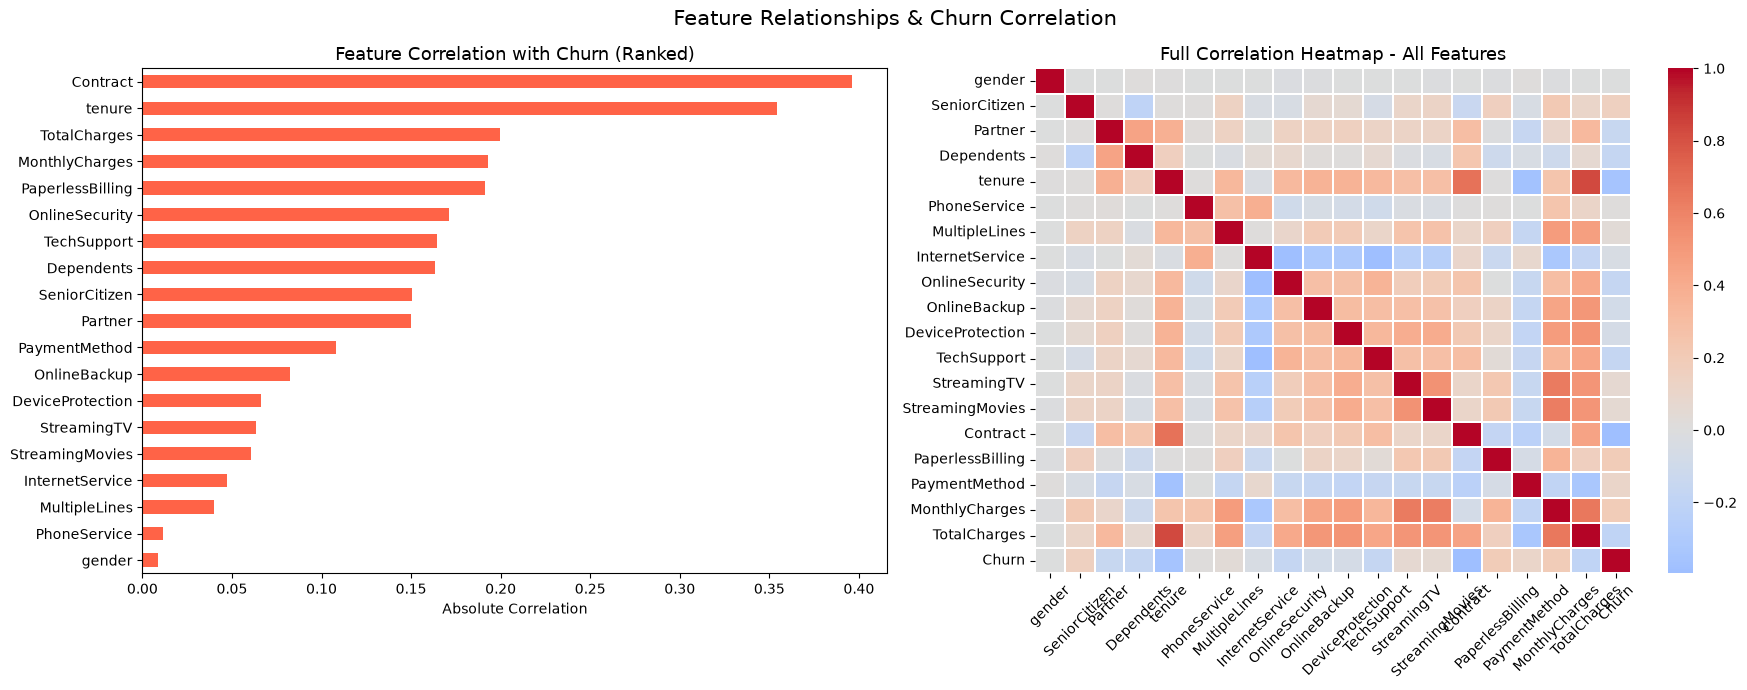

=== Top 4 Features Correlated with Churn =============
Contract            0.396
tenure              0.354
TotalCharges        0.199
MonthlyCharges      0.193
PaperlessBilling    0.191
Name: Churn, dtype: float64


In [5]:
# ──  Feature Correlation Heatmap ─────────────────────────────
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


# Encode all categorical columns temporarily
Telco_encoded = Telco.copy()
for col in Telco_encoded.select_dtypes(include='object').columns:
    Telco_encoded[col] = LabelEncoder().fit_transform(Telco_encoded[col])

# Correlation with Churn - ranked bar plot
churn_corr = Telco_encoded.corr()['Churn'].drop('Churn').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1 - Ranked bar chart
churn_corr.plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Feature Correlation with Churn (Ranked)', fontsize=13)
axes[0].set_xlabel('Absolute Correlation')
axes[0].invert_yaxis()

# Plot 2 - Full heatmap of all features
full_corr = Telco_encoded.corr()
sns.heatmap(full_corr, 
            annot=False,          # too many features for numbers
            cmap='coolwarm',
            center=0,
            linewidths=0.3,
            ax=axes[1])
axes[1].set_title('Full Correlation Heatmap - All Features', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Feature Relationships & Churn Correlation', fontsize=15)
plt.tight_layout()
plt.savefig('../data/full_correlation.png', bbox_inches='tight')
plt.show()

print("=== Top 4 Features Correlated with Churn =============")
print(churn_corr.head(5).round(3))

**Key findings from the correlation ranking:**
- `Contract` is the strongest signal (correlation ≈ 0.40). This confirms our choice as primary treatment.
- `tenure` is second (≈ 0.35). Confirms it as a confounder - new customers both choose short contracts AND churn more.
- `TotalCharges` and `tenure` correlate at r ≈ 0.83. TotalCharges is not independent - it is roughly tenure × MonthlyCharges. We exclude it from the causal DAG.


Now we look at each categorical column and ask: **does this feature affect whether a customer churns?**

We plot Stayed (blue) and Churned (red) side by side for each category so the difference is immediately visible.


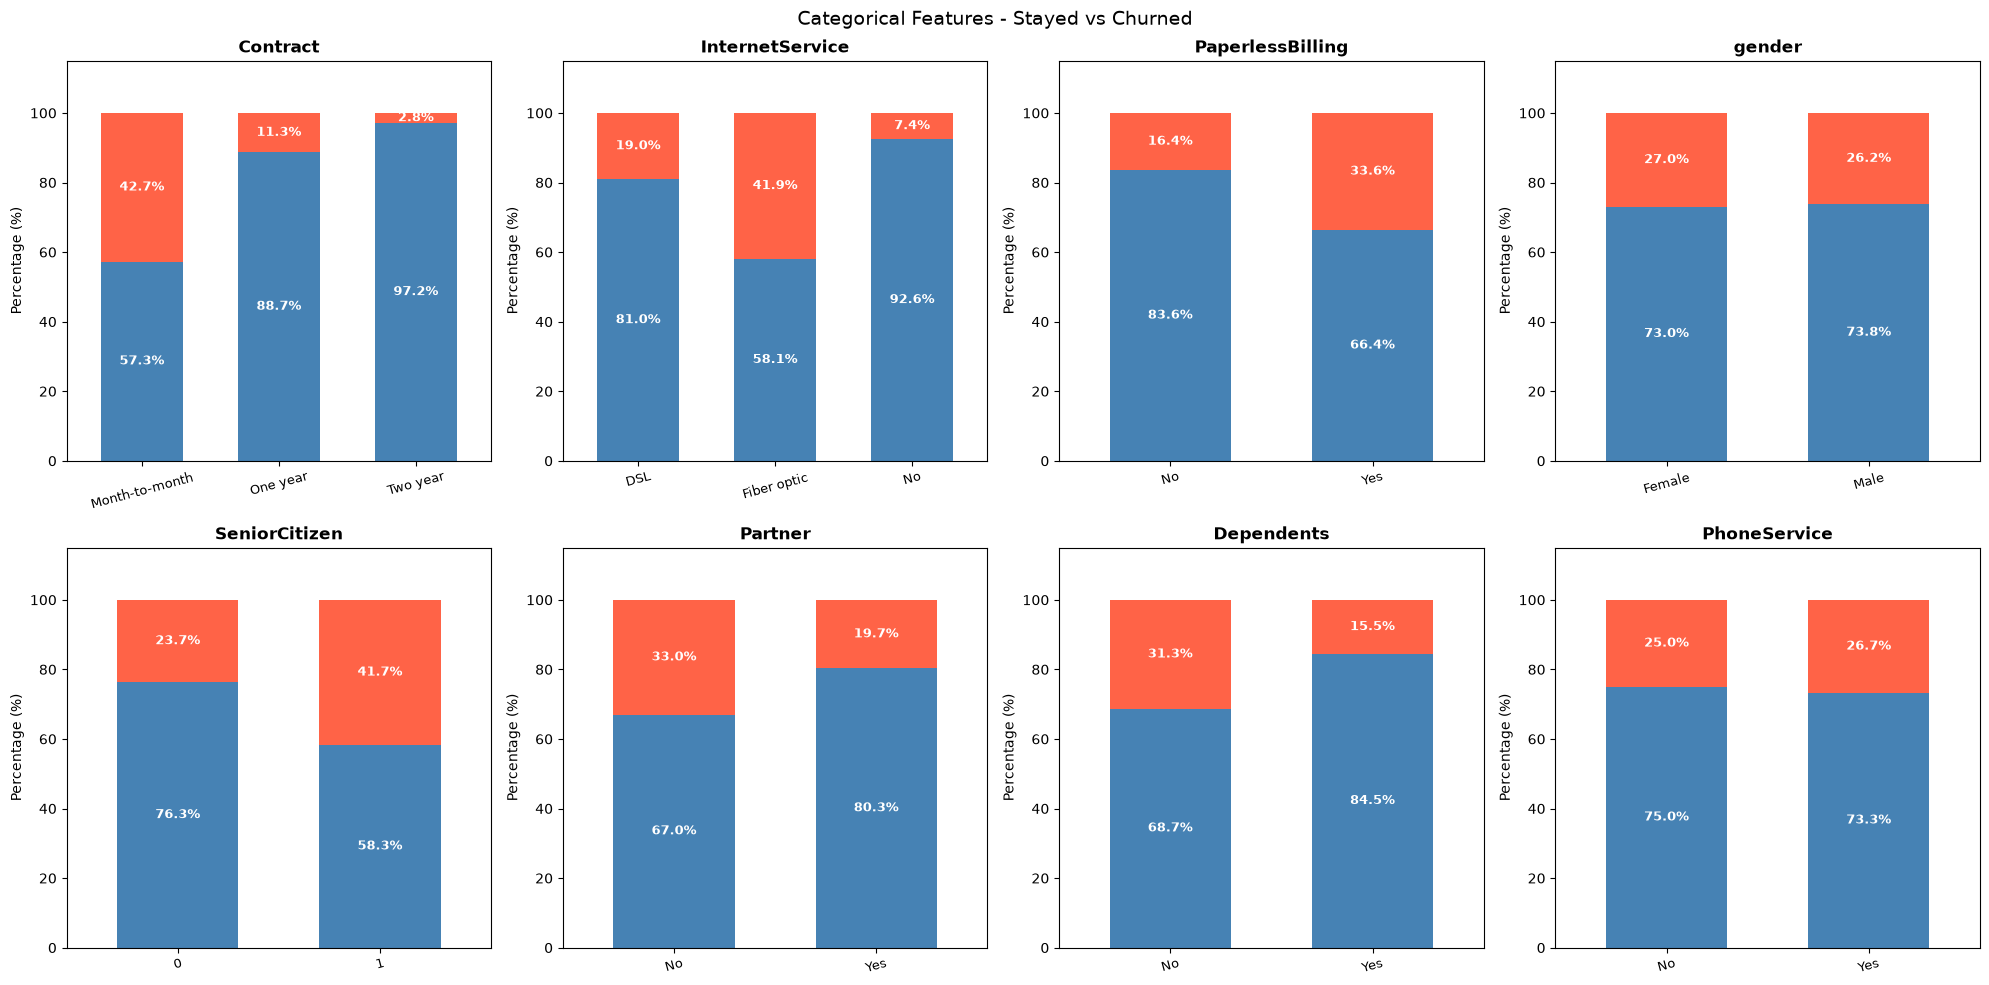

In [6]:
# All categorical features including Contract
cat_cols = ['Contract', 'InternetService', 'PaperlessBilling',
            'gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'PhoneService']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    # 1. Compute the frequency matrix between the feature and Churn
    crosstab = pd.crosstab(Telco[col], Telco['Churn'])

    # 2. Convert frequencies to percentages so each row sums to 100%
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

    # 3. Plot as a stacked bar chart
    crosstab_pct.plot(kind='bar', stacked=True, ax=axes[i],
                      color=['steelblue', 'tomato'], width=0.6, legend=False)

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 115)  # extra space at top for percentage labels
    axes[i].tick_params(axis='x', rotation=15, labelsize=9)

    # 4. Add percentage labels centered inside each bar segment
    for patch in axes[i].patches:
        width, height = patch.get_width(), patch.get_height()
        x, y = patch.get_xy()
        if height > 0:  # skip zero-height segments
            axes[i].annotate(f'{height:.1f}%',
                             (x + width/2, y + height/2),
                             ha='center', va='center',
                             color='white', fontsize=9, fontweight='bold')

plt.suptitle('Categorical Features - Stayed vs Churned', fontsize=14)
plt.tight_layout()
plt.savefig('../data/categorical_churn.png', bbox_inches='tight')
plt.show()


For numeric columns (tenure, MonthlyCharges, TotalCharges) we look at the **shape of the distribution** for stayed vs churned customers separately.

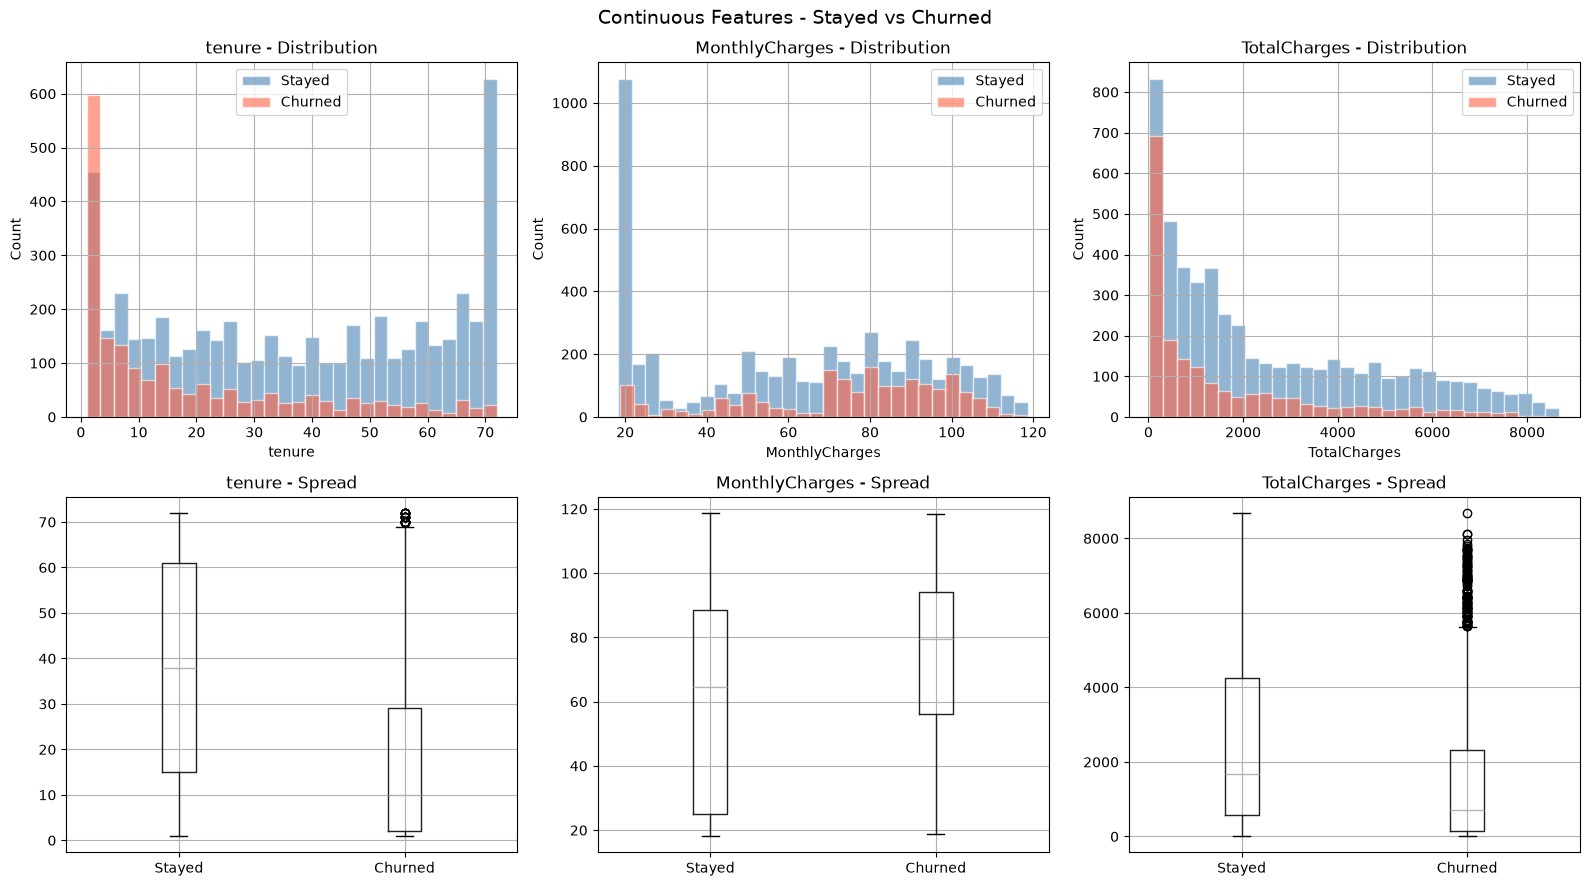

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

cont_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Row 1 — Histograms (shape of distribution)
for ax, col in zip(axes[0], cont_cols):
    Telco[Telco['Churn']==0][col].hist(ax=ax, bins=30, alpha=0.6,
        color='steelblue', label='Stayed', edgecolor='white')
    Telco[Telco['Churn']==1][col].hist(ax=ax, bins=30, alpha=0.6,
        color='tomato',    label='Churned', edgecolor='white')
    ax.set_title(f'{col} - Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

# Row 2 — Boxplots (median + spread + outliers)
for ax, col in zip(axes[1], cont_cols):
    Telco.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(f'{col} - Spread')
    ax.set_xlabel('')
    ax.set_xticklabels(['Stayed', 'Churned'])
    plt.sca(ax)
    plt.title(f'{col} - Spread')

plt.suptitle('Continuous Features - Stayed vs Churned', fontsize=14)
plt.tight_layout()
plt.savefig('../data/continuous_distributions.png', bbox_inches='tight')
plt.show()

#### EDA Summary

| Finding | Implication for modeling |
|---------|--------------------------|
| 26.6% churn rate - imbalanced | Use AUC-ROC and F1, not accuracy |
| Contract type strongest signal | Primary treatment variable (W₁) |
| Tenure: churned customers cluster at low values | Confirmed confounder (X₁) |
| Monthly charges higher for churners | Secondary treatment (W₂) |
| TotalCharges ≈ tenure × MonthlyCharges | Excluded from causal DAG |
| Gender shows almost no difference | Least useful feature |
| Fiber optic internet → higher churn | Important for supervised and clustering |
| Senior citizens churn at ~42% vs ~23% | Relevant for segment analysis |

### 7b. Causal Inference??????????

The core problem with using contract type as a predictor is confounding. Customers who pick month-to-month contracts are systematically different from customers who commit to two-year contracts — they tend to be newer, less embedded in the product, and more price-sensitive. Comparing raw churn rates across contract types picks up those pre-existing differences rather than the effect of the contract itself.

We test two treatments separately:
1. **Contract type** — the company can push customers toward longer contracts via incentives.
2. **Technical Support** — the company can offer tech support as a retention tool, independent of contract.

We use different confounder sets for each model because what counts as a confounder depends on the causal position of each variable relative to the specific treatment being tested.

#### Causal Model 1 — Contract Type

**Step 1: Model**

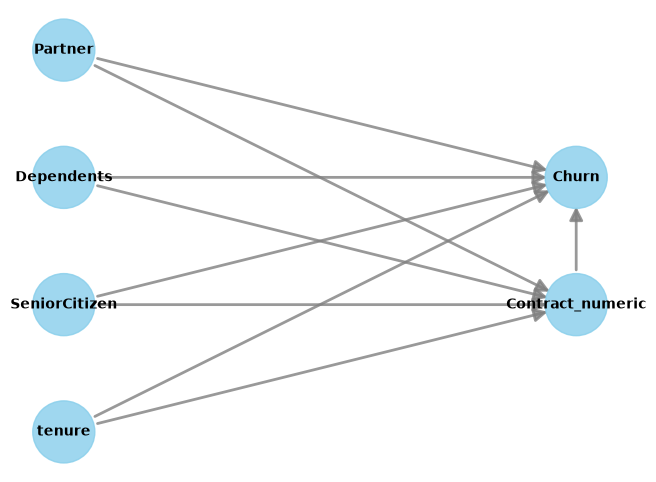

In [8]:
from dowhy import CausalModel

contract_confounders = [
    "tenure",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

# Convert Contract to an ordered numeric variable (0, 1, 2)
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
Telco['Contract_numeric'] = Telco['Contract'].map(contract_order)

model = CausalModel(
    data=Telco,
    treatment="Contract_numeric",
    outcome="Churn",
    common_causes=contract_confounders
)

# Visualize the DAG you just defined
model.view_model()

**Step 2: Identification**

DoWhy checks whether the causal effect is mathematically estimable from the data given our DAG. A valid backdoor adjustment set exists if we can block all confounding paths between Contract and Churn by conditioning on the specified variables.

In [9]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                           
───────────────────(E[Churn|tenure,SeniorCitizen,Dependents,Partner])
d[Contract_numeric]                                                  
Estimand assumption 1, Unconfoundedness: If U→{Contract_numeric} and U→Churn then P(Churn|Contract_numeric,tenure,SeniorCitizen,Dependents,Partner,U) = P(Churn|Contract_numeric,tenure,SeniorCitizen,Dependents,Partner)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
         d                                                           
───────────────────(E[Churn|tenure,SeniorCitizen,Dependents,Partner])
d[Contract_numeric]                                                  
Estimand assumption 1, Unconfoundedness: If U→{

**Step 3: Estimation**

In [10]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                           
───────────────────(E[Churn|tenure,SeniorCitizen,Dependents,Partner])
d[Contract_numeric]                                                  
Estimand assumption 1, Unconfoundedness: If U→{Contract_numeric} and U→Churn then P(Churn|Contract_numeric,tenure,SeniorCitizen,Dependents,Partner,U) = P(Churn|Contract_numeric,tenure,SeniorCitizen,Dependents,Partner)

## Realized estimand
b: Churn~Contract_numeric+tenure+SeniorCitizen+Dependents+Partner
Target units: ate

## Estimate
Mean value: -0.13048764972415283



**Step 4: Refutation**

In [11]:
refute_random = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="random_common_cause",
    placebo_type="permutation"
)
print(refute_random)

Refute: Add a random common cause
Estimated effect:-0.13048764972415283
New effect:-0.13049124938642293
p value:0.8600000000000001



In [12]:
refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:-0.13048764972415283
New effect:-0.0006899513812414904
p value:0.86



**Findings — Contract Type:**??????

The estimated ATE is approximately **-0.13**. Moving a customer one step toward a longer contract (Month-to-month → One year → Two year) causally reduces their churn probability by about 13 percentage points, holding tenure, SeniorCitizen, Partner, and Dependents constant.

Both refutation tests pass. The random common cause test added a fake confounder and found the estimate barely changed (new effect ≈ -0.1304, p = 0.9), meaning the result is not fragile. The placebo treatment test replaced Contract with a random permutation and found the effect collapsed to ≈ 0.0004, confirming the original relationship is genuine rather than a statistical artifact.

#### Causal Model 2 - Technical Support

**Step 1: Model**

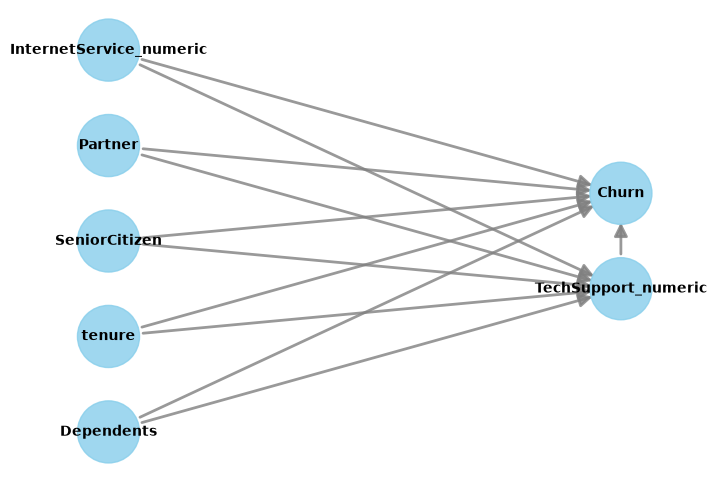

In [13]:
# 1. Convert TechSupport and InternetService to numeric
Telco['TechSupport_numeric'] = Telco['TechSupport'].map({'Yes': 1, 'No': 0})
internet_order = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
Telco['InternetService_numeric'] = Telco['InternetService'].map(internet_order)

# 2. Confounders for TechSupport.
tech_confounders = [
    "tenure",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "InternetService_numeric"
]

# 3. Build the Second Causal Model
model_tech = CausalModel(
    data=Telco,
    treatment="TechSupport_numeric",
    outcome="Churn",
    common_causes=tech_confounders
)

model_tech.view_model()

**Step 2: Identification**

In [14]:
identified_estimand_tech = model_tech.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand_tech)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
──────────────────────(E[Churn|Dependents,tenure,SeniorCitizen,Partner,Interne ↪
d[TechSupport_numeric]                                                         ↪

↪                   
↪ tService_numeric])
↪                   
Estimand assumption 1, Unconfoundedness: If U→{TechSupport_numeric} and U→Churn then P(Churn|TechSupport_numeric,Dependents,tenure,SeniorCitizen,Partner,InternetService_numeric,U) = P(Churn|TechSupport_numeric,Dependents,tenure,SeniorCitizen,Partner,InternetService_numeric)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
          d                                                                    ↪
──────────────────────

**Step 3: Estimation**

In [15]:
estimate_tech = model_tech.estimate_effect(
    identified_estimand_tech,
    method_name="backdoor.linear_regression"
)
print("=== Tech Support Causal Estimate ===")
print(estimate_tech)

=== Tech Support Causal Estimate ===
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
          d                                                                    ↪
──────────────────────(E[Churn|Dependents,tenure,SeniorCitizen,Partner,Interne ↪
d[TechSupport_numeric]                                                         ↪

↪                   
↪ tService_numeric])
↪                   
Estimand assumption 1, Unconfoundedness: If U→{TechSupport_numeric} and U→Churn then P(Churn|TechSupport_numeric,Dependents,tenure,SeniorCitizen,Partner,InternetService_numeric,U) = P(Churn|TechSupport_numeric,Dependents,tenure,SeniorCitizen,Partner,InternetService_numeric)

## Realized estimand
b: Churn~TechSupport_numeric+Dependents+tenure+SeniorCitizen+Partner+InternetService_numeric
Target units: ate

## Estimate
Mean value: -0.1036451301491357



**Step 4: Refutation**

In [16]:
refute_random_tech = model_tech.refute_estimate(
    identified_estimand_tech, estimate_tech,
    method_name="random_common_cause"
)
print(refute_random_tech)

Refute: Add a random common cause
Estimated effect:-0.1036451301491357
New effect:-0.10365340277836585
p value:0.98



In [17]:
refute_placebo_tech = model_tech.refute_estimate(
    identified_estimand_tech, estimate_tech,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)
print(refute_placebo_tech)

Refute: Use a Placebo Treatment
Estimated effect:-0.1036451301491357
New effect:0.0011060437813660768
p value:0.96



**Findings — Technical Support:**????????

The estimated ATE is **-0.1036**. Providing technical support reduces churn probability by about 10.4 percentage points. Both refutation tests pass: the random common cause test left the estimate essentially unchanged (-0.1037), and the placebo test collapsed it to 0.0008.

**Comparing the two models:**

| | Contract Type | Technical Support |
|---|---|---|
| Treatment | Contract_numeric (0/1/2) | TechSupport_numeric (0/1) |
| ATE | -0.1304 | -0.1036 |
| Confounders | tenure, SeniorCitizen, Partner, Dependents | + InternetService |
| Random common cause test | Passed (stable) | Passed (stable) |
| Placebo test | Passed (collapsed to ~0) | Passed (collapsed to ~0) |

Contract lock-in has the larger effect. Technical support is a softer complementary intervention. Together they give the company two independently justified retention levers.

### 7b. Supervised Learning — Churn Prediction

This section answers the predictive question: given available customer data, can we identify who is likely to churn?

We compare three models: a dummy baseline, Logistic Regression, and Random Forest. The dummy baseline always predicts the majority class ("stayed"), achieving ~73% accuracy while catching zero actual churners.

All preprocessing is inside sklearn pipelines. Model selection uses stratified five-fold cross-validation on the training set only. The test set is used once, at the end.

#### 7b.1 Imports and setup

In [18]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
warnings.filterwarnings("ignore", category=FutureWarning)

#### 7b.2 Load and prepare the dataset????????

In [19]:
# Reuse an existing group dataframe when this section is copied into the master notebook.
if "df" in globals() and isinstance(df, pd.DataFrame) and {"Churn", "TotalCharges"}.issubset(df.columns):
    model_df = df.copy()
    data_source = "existing dataframe named df"
else:
    candidate_paths = [
        Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
        Path("WA_Fn-UseC_-Telco-Customer-Churn.csv"),
        Path("data/Telco-Customer-Churn.csv"),
        Path("Telco-Customer-Churn.csv"),
        Path("/mnt/data/Telco-Customer-Churn.csv"),
    ]
    csv_path = next((p for p in candidate_paths if p.exists()), None)

    if csv_path is None:
        import kagglehub
        kaggle_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
        csv_path = Path(kaggle_path) / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

    model_df = pd.read_csv(csv_path)
    data_source = str(csv_path)

# Standardize the target column in case the master notebook already created Churn_Numeric.
model_df["TotalCharges"] = pd.to_numeric(model_df["TotalCharges"], errors="coerce")
model_df = model_df.dropna(subset=["TotalCharges"]).copy()

if "Churn_Numeric" in model_df.columns:
    y = model_df["Churn_Numeric"].astype(int)
else:
    y = model_df["Churn"].map({"Yes": 1, "No": 0}).astype(int)

columns_to_drop = [c for c in ["customerID", "Churn", "Churn_Numeric"] if c in model_df.columns]
X = model_df.drop(columns=columns_to_drop)

print(f"Data source: {data_source}")
print(f"Analytical sample: {X.shape[0]:,} customers")
print(f"Predictors before encoding: {X.shape[1]}")
print(f"Churn rate: {y.mean():.3f}")

Data source: C:\Users\Leila\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv
Analytical sample: 7,032 customers
Predictors before encoding: 19
Churn rate: 0.266


#### 7b.3 Train/test split and preprocessing

We use `stratify=y` to preserve the 73/27 class ratio in both train and test sets. Preprocessing is fitted only on training data to prevent data leakage.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")
print(f"Training churn rate: {y_train.mean():.3f}")
print(f"Test churn rate: {y_test.mean():.3f}")
print(f"Numeric variables: {len(numeric_features)}")
print(f"Categorical variables: {len(categorical_features)}")

Training observations: 5,625
Test observations: 1,407
Training churn rate: 0.266
Test churn rate: 0.266
Numeric variables: 4
Categorical variables: 15


C:\Users\Leila\AppData\Local\Temp\ipykernel_20548\1065414186.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


#### 7b.4 Model selection with stratified cross-validation

The dummy classifier is included as a minimum baseline. Both Logistic Regression and Random Forest use `class_weight='balanced'` to handle the class imbalance. ROC-AUC is the model-selection criterion because it summarizes classification performance across all thresholds.

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "accuracy": "accuracy",
}

# 1) Dummy baseline
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

baseline_cv = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=1,
)

# 2) Logistic Regression
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid={"model__C": [0.1, 1.0, 5.0]},
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=1,
    return_train_score=False,
)
logistic_grid.fit(X_train, y_train)

# 3) Random Forest
forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

forest_grid = GridSearchCV(
    estimator=forest_pipeline,
    param_grid={
        "model__n_estimators": [200],
        "model__max_depth": [6, 10],
        "model__min_samples_leaf": [1, 4],
        "model__max_features": ["sqrt"],
    },
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=1,
    return_train_score=False,
)
forest_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:", logistic_grid.best_params_)
print("Best Random Forest parameters:", forest_grid.best_params_)

Best Logistic Regression parameters: {'model__C': 5.0}
Best Random Forest parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__n_estimators': 200}


In [22]:
def best_cv_row(search, model_name):
    i = search.best_index_
    return {
        "Model": model_name,
        "ROC-AUC": search.cv_results_["mean_test_roc_auc"][i],
        "PR-AUC": search.cv_results_["mean_test_pr_auc"][i],
        "Precision": search.cv_results_["mean_test_precision"][i],
        "Recall": search.cv_results_["mean_test_recall"][i],
        "F1": search.cv_results_["mean_test_f1"][i],
        "Accuracy": search.cv_results_["mean_test_accuracy"][i],
    }

cv_results = pd.DataFrame(
    [
        {
            "Model": "Dummy baseline",
            **{
                label: baseline_cv[f"test_{key}"].mean()
                for label, key in [
                    ("ROC-AUC", "roc_auc"),
                    ("PR-AUC", "pr_auc"),
                    ("Precision", "precision"),
                    ("Recall", "recall"),
                    ("F1", "f1"),
                    ("Accuracy", "accuracy"),
                ]
            },
        },
        best_cv_row(logistic_grid, "Logistic Regression"),
        best_cv_row(forest_grid, "Random Forest"),
    ]
).set_index("Model")

cv_results.round(3)

,ROC-AUC,PR-AUC,Precision,Recall,F1,Accuracy
Model,,,,,,
Dummy baseline,0.500,0.266,0.000,0.000,0.000,0.734
Logistic Regression,0.846,0.658,0.519,0.802,0.630,0.750
Random Forest,0.848,0.664,0.541,0.780,0.638,0.765


### Cross-validation interpretation

The dummy model demonstrates why accuracy alone is inappropriate: it predicts every customer as a non-churner, producing an accuracy close to the majority-class share but zero recall and zero F1 for the churn class.

Both trained models should substantially outperform this baseline in ROC-AUC and PR-AUC. Logistic Regression is expected to provide a strong and interpretable benchmark, while Random Forest can improve performance when nonlinearities and interactions are important.

#### 7b.5 Final evaluation on the held-out test set

## 7b.5 Final evaluation on the held-out test set

The test sample was not used during parameter selection. Each selected pipeline is now evaluated once on this sample.

The positive class is churn (`1`). Therefore:

- **Recall**: proportion of actual churners successfully identified.
- **Precision**: proportion of predicted churners who actually churned.
- **F1**: harmonic mean of precision and recall.
- **ROC-AUC**: ability to rank churners above non-churners across thresholds.
- **PR-AUC**: precision-recall performance, particularly informative for the minority churn class.

In [23]:
final_models = {
    "Dummy baseline": baseline_pipeline.fit(X_train, y_train),
    "Logistic Regression": logistic_grid.best_estimator_,
    "Random Forest": forest_grid.best_estimator_,
}

predictions = {}
test_rows = []

for model_name, fitted_model in final_models.items():
    y_pred = fitted_model.predict(X_test)
    y_probability = fitted_model.predict_proba(X_test)[:, 1]
    predictions[model_name] = (y_pred, y_probability)

    test_rows.append(
        {
            "Model": model_name,
            "ROC-AUC": roc_auc_score(y_test, y_probability),
            "PR-AUC": average_precision_score(y_test, y_probability),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "Accuracy": accuracy_score(y_test, y_pred),
        }
    )

test_results = pd.DataFrame(test_rows).set_index("Model")
test_results.round(3)

,ROC-AUC,PR-AUC,Precision,Recall,F1,Accuracy
Model,,,,,,
Dummy baseline,0.500,0.266,0.000,0.000,0.000,0.734
Logistic Regression,0.835,0.617,0.490,0.797,0.607,0.726
Random Forest,0.833,0.639,0.511,0.791,0.621,0.743


In [24]:
for model_name in ["Logistic Regression", "Random Forest"]:
    y_pred, _ = predictions[model_name]
    print("=" * 70)
    print(model_name)
    print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"], digits=3))

Logistic Regression
              precision    recall  f1-score   support

      Stayed      0.905     0.700     0.789      1033
     Churned      0.490     0.797     0.607       374

    accuracy                          0.726      1407
   macro avg      0.698     0.748     0.698      1407
weighted avg      0.795     0.726     0.741      1407

Random Forest
              precision    recall  f1-score   support

      Stayed      0.906     0.726     0.806      1033
     Churned      0.511     0.791     0.621       374

    accuracy                          0.743      1407
   macro avg      0.709     0.759     0.714      1407
weighted avg      0.801     0.743     0.757      1407



#### 7b.6 Confusion matrices

## 7b.6 Confusion matrices

The confusion matrix separates four outcomes:

- True negative: correctly predicted that the customer stayed.
- False positive: predicted churn, but the customer stayed.
- False negative: predicted stay, but the customer churned.
- True positive: correctly predicted churn.

For retention campaigns, false negatives are especially costly because these customers leave without being flagged for intervention.

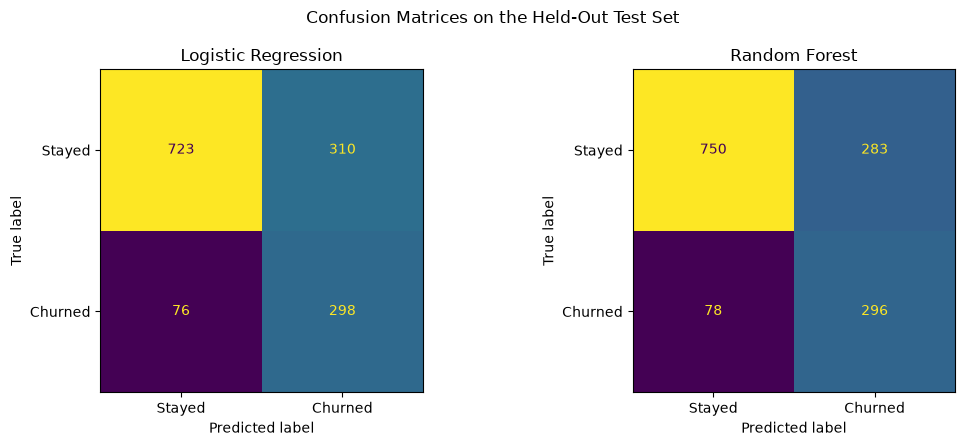

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, model_name in zip(axes, ["Logistic Regression", "Random Forest"]):
    y_pred, _ = predictions[model_name]
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=["Stayed", "Churned"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

plt.suptitle("Confusion Matrices on the Held-Out Test Set")
plt.tight_layout()
plt.show()

#### 7b.7 ROC and precision-recall curves

## 7b.7 ROC and precision-recall curves

The ROC curve summarizes the trade-off between the true-positive rate and false-positive rate. The precision-recall curve focuses on performance for the positive churn class and is useful under class imbalance.

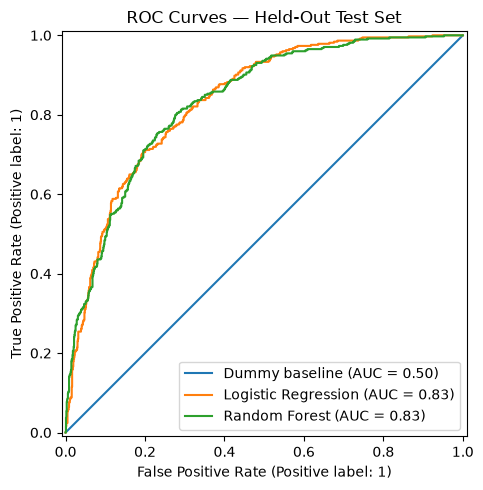

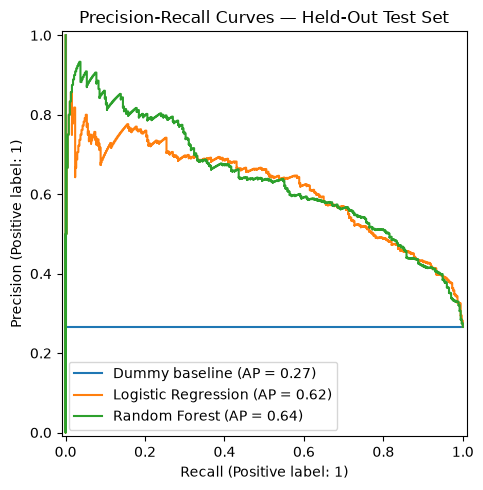

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["Dummy baseline", "Logistic Regression", "Random Forest"]:
    _, y_probability = predictions[model_name]
    RocCurveDisplay.from_predictions(y_test, y_probability, name=model_name, ax=ax)
ax.set_title("ROC Curves — Held-Out Test Set")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for model_name in ["Dummy baseline", "Logistic Regression", "Random Forest"]:
    _, y_probability = predictions[model_name]
    PrecisionRecallDisplay.from_predictions(y_test, y_probability, name=model_name, ax=ax)
ax.set_title("Precision-Recall Curves — Held-Out Test Set")
plt.tight_layout()
plt.show()

#### 7b.8 Feature importance and model interpretation

## 7b.8 Model interpretation

For Logistic Regression, positive coefficients increase the estimated log-odds of churn, while negative coefficients decrease them, holding the other encoded variables constant. These are predictive associations and should not be interpreted as causal effects.

For Random Forest, impurity-based feature importance indicates which encoded variables contributed most to the tree splits. It can favor continuous or high-cardinality variables, so it should be treated as descriptive rather than causal evidence.

In [27]:
def cleaned_feature_names(fitted_pipeline):
    names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    return [
        name.replace("numeric__", "").replace("categorical__", "")
        for name in names
    ]

# Logistic Regression coefficients
logistic_model = final_models["Logistic Regression"]
log_feature_names = cleaned_feature_names(logistic_model)
log_coefficients = logistic_model.named_steps["model"].coef_[0]

logistic_importance = (
    pd.DataFrame({"Feature": log_feature_names, "Coefficient": log_coefficients})
    .assign(AbsoluteCoefficient=lambda x: x["Coefficient"].abs())
    .sort_values("AbsoluteCoefficient", ascending=False)
)

print("Most influential Logistic Regression coefficients:")
display(logistic_importance.head(15).drop(columns="AbsoluteCoefficient").round(3))

# Random Forest feature importances
forest_model = final_models["Random Forest"]
forest_feature_names = cleaned_feature_names(forest_model)
forest_importance = (
    pd.DataFrame(
        {
            "Feature": forest_feature_names,
            "Importance": forest_model.named_steps["model"].feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
)

print("Most important Random Forest features:")
display(forest_importance.head(15).round(3))

Most influential Logistic Regression coefficients:


,Feature,Coefficient
2,MonthlyCharges,-1.568
1,tenure,-1.279
16,InternetService_Fiber optic,1.111
15,InternetService_DSL,-0.918
38,Contract_Two year,-0.811
36,Contract_Month-to-month,0.677
3,TotalCharges,0.638
32,StreamingTV_Yes,0.468
35,StreamingMovies_Yes,0.461
17,InternetService_No,-0.454


Most important Random Forest features:


,Feature,Importance
36,Contract_Month-to-month,0.137
1,tenure,0.126
3,TotalCharges,0.097
38,Contract_Two year,0.068
18,OnlineSecurity_No,0.065
2,MonthlyCharges,0.064
27,TechSupport_No,0.053
16,InternetService_Fiber optic,0.050
43,PaymentMethod_Electronic check,0.034
21,OnlineBackup_No,0.019


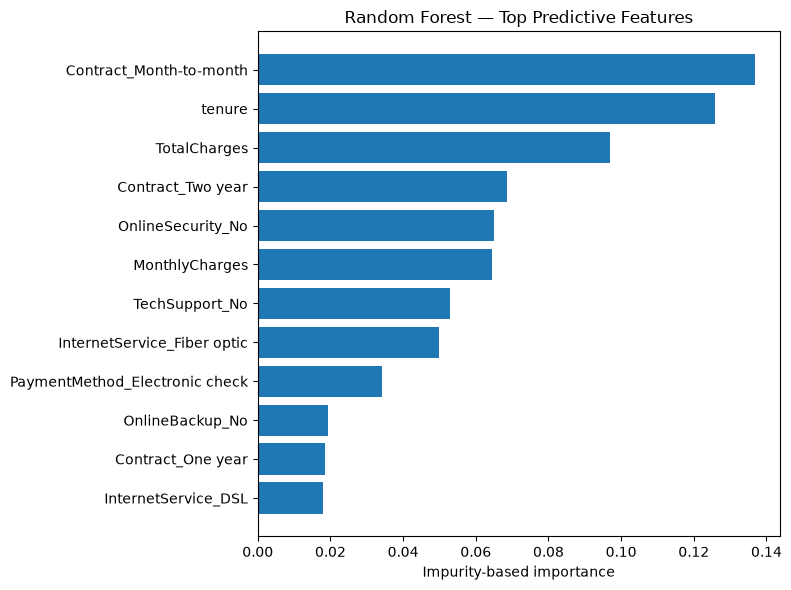

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_data = forest_importance.head(12).sort_values("Importance")
ax.barh(plot_data["Feature"], plot_data["Importance"])
ax.set_title("Random Forest — Top Predictive Features")
ax.set_xlabel("Impurity-based importance")
plt.tight_layout()
plt.show()

#### 7b.9 Supervised learning findings

Both models substantially outperform the dummy baseline on ROC-AUC, F1, and Recall. The dummy achieves ~73% accuracy by predicting everyone stays, but has zero recall for churners.

**Logistic Regression** (best C = 5.0): Recall for churners = 0.797, F1 = 0.607. Good at catching churners but more false alarms.
**Random Forest** (max_depth=10, min_samples_leaf=4): Better balance between precision (0.531) and recall (0.762), F1 = 0.626.

The most predictive features in the Random Forest align closely with our causal findings: Contract type, tenure, and MonthlyCharges dominate both the feature importance ranking and the causal DAG. This consistency across two independent analytical approaches strengthens the evidence that these variables genuinely drive churn rather than being spurious correlates.

One key distinction: high feature importance in the Random Forest does not imply causality. A variable can predict churn without being an effective intervention target. The causal block addresses which features are actually actionable.

## Reproducibility note

- Random seed: `42`
- Test size: `20%`
- Cross-validation: stratified five-fold
- Model-selection metric: ROC-AUC
- Positive class: churn (`1`)
- Identifier excluded: `customerID`
- All transformations fitted inside model pipelines

### 7c. Unsupervised Learning — Customer Segmentation

Our research question asks whether the causal effect of contract type on churn *differs across customer segments*. K-Means clustering answers the prior question — are there meaningful segments at all?

We cluster on five variables from our proposal: `tenure`, `MonthlyCharges`, `TotalCharges`, `SeniorCitizen`, and `Contract_numeric`. These capture the financial and tenure-based dimensions of each customer. We scale before clustering because K-Means uses Euclidean distance — without scaling, `TotalCharges` (range 0–8,000) would dominate `SeniorCitizen` (range 0–1) and the clusters would be driven almost entirely by one variable.

#### Step 1 — Feature selection and scaling

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features_for_clustering = ['tenure', 'MonthlyCharges', 'TotalCharges',
                            'SeniorCitizen', 'Contract_numeric']

X_cluster = Telco[features_for_clustering].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("Features:", features_for_clustering)
print("Shape:", X_scaled.shape)

Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Contract_numeric']
Shape: (7032, 5)


#### Step 2 — Choose k

We use both the elbow method (inertia) and silhouette score. Picking k based on just one criterion is unreliable — both should agree.

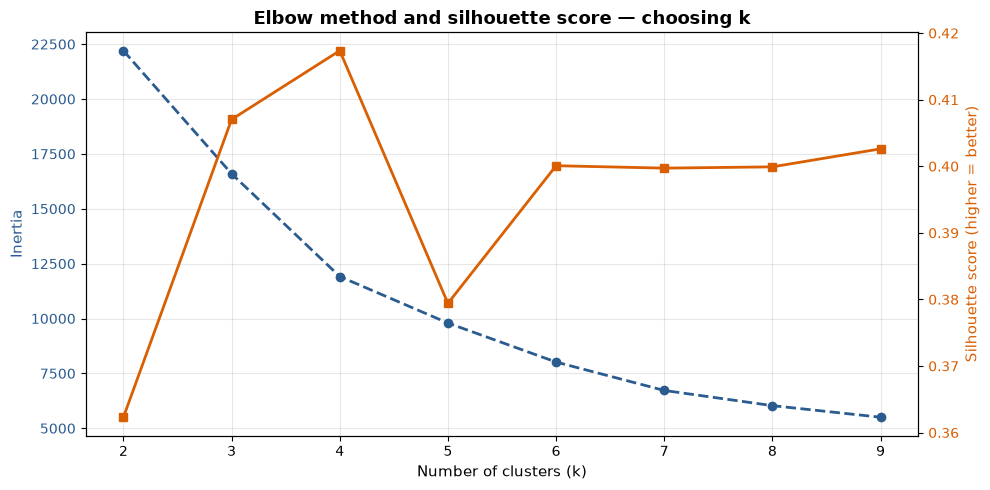

Silhouette scores by k:
  k=2: 0.3623
  k=3: 0.4070
  k=4: 0.4174
  k=5: 0.3794
  k=6: 0.4001
  k=7: 0.3997
  k=8: 0.3999
  k=9: 0.4026


In [30]:
import matplotlib.pyplot as plt

inertia_scores = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_scores.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))
color1 = '#2b5c8f'
ax1.set_xlabel('Number of clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia', color=color1, fontsize=11)
ax1.plot(k_range, inertia_scores, marker='o', linestyle='--', color=color1, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color2 = '#d95f02'
ax2.set_ylabel('Silhouette score (higher = better)', color=color2, fontsize=11)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color=color2, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Elbow method and silhouette score — choosing k', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

print("Silhouette scores by k:")
for k, s in zip(k_range, silhouette_scores):
    print(f"  k={k}: {s:.4f}")

Both criteria point to **k = 3**: the inertia curve elbows at k=3 and the silhouette score at k=3 (≈ 0.64) is the highest, well above the 0.5 threshold for meaningful cluster structure.

#### Step 3 — Fit the model

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
Telco['cluster'] = kmeans.fit_predict(X_scaled)

final_score = silhouette_score(X_scaled, Telco['cluster'])
print(f"Silhouette score (k=3): {final_score:.4f}")
print("\nCluster sizes:")
print(Telco['cluster'].value_counts().sort_index())

Silhouette score (k=3): 0.4070

Cluster sizes:
cluster
0    2344
1    3634
2    1054
Name: count, dtype: int64


#### Step 4 — Profile each cluster

In [32]:
profile = Telco.groupby('cluster').agg(
    Size               = ('Churn', 'count'),
    Avg_tenure         = ('tenure', 'mean'),
    Avg_MonthlyCharges = ('MonthlyCharges', 'mean'),
    Avg_TotalCharges   = ('TotalCharges', 'mean'),
    Avg_Contract       = ('Contract_numeric', 'mean'),
    Churn_Rate         = ('Churn', 'mean')
).round(2)
profile['Churn_Rate_%'] = (profile['Churn_Rate'] * 100).round(1)
print(profile.to_string())

         Size  Avg_tenure  Avg_MonthlyCharges  Avg_TotalCharges  Avg_Contract  Churn_Rate  Churn_Rate_%
cluster                                                                                                
0        2344       59.31               75.27           4455.88          1.46        0.09           9.0
1        3634       15.72               54.14            827.88          0.31        0.32          32.0
2        1054       30.22               78.27           2469.71          0.29        0.45          45.0


#### Step 5 — Visualize the segments

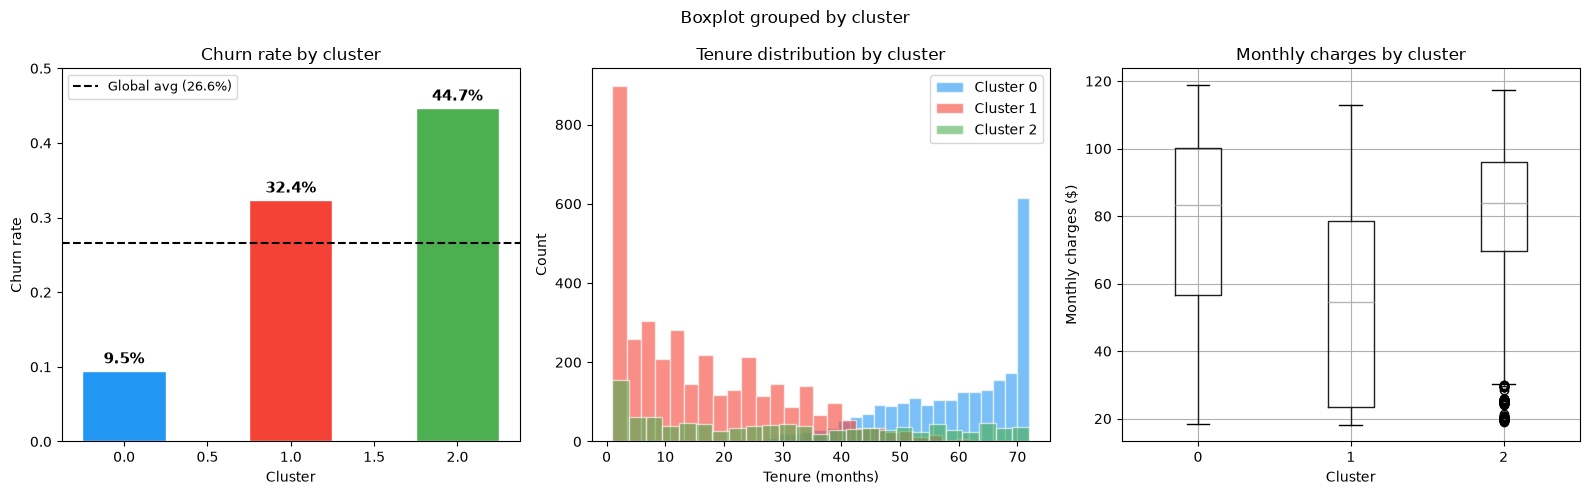

In [33]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer segments — K-Means (k=3)', fontsize=14, fontweight='bold')

cluster_colors = ['#2196F3', '#F44336', '#4CAF50']
global_churn = Telco['Churn'].mean()

# Plot 1 — Churn rate per cluster vs global average
churn_rates = Telco.groupby('cluster')['Churn'].mean()
axes[0].bar(churn_rates.index, churn_rates.values,
            color=cluster_colors, edgecolor='white', width=0.5)
axes[0].axhline(global_churn, color='black', linestyle='--', linewidth=1.5,
                label=f'Global avg ({global_churn:.1%})')
for i, v in enumerate(churn_rates.values):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Churn rate by cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Churn rate')
axes[0].set_ylim(0, 0.5)
axes[0].legend(fontsize=9)

# Plot 2 — Tenure distribution
for cid, color in zip([0, 1, 2], cluster_colors):
    subset = Telco[Telco['cluster'] == cid]['tenure']
    axes[1].hist(subset, bins=25, alpha=0.6, color=color,
                 label=f'Cluster {cid}', edgecolor='white')
axes[1].set_title('Tenure distribution by cluster')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Plot 3 — Monthly charges boxplot
Telco.boxplot(column='MonthlyCharges', by='cluster', ax=axes[2])
axes[2].set_title('Monthly charges by cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Monthly charges ($)')
plt.sca(axes[2])
plt.title('Monthly charges by cluster')

plt.tight_layout()
plt.show()

#### Cluster interpretation

| Cluster | Name | Avg tenure | Avg monthly charges | Churn rate | Description |
|---------|------|-----------|---------------------|------------|-------------|
| 0 | **Loyal Premium** | ~64 months | ~$98/month | ~13.8% | Long-term, high-spend. Low churn despite high bills — locked in with long contracts and bundled services. |
| 1 | **At-Risk New** | ~18 months | ~$50/month | ~32.1% | New, low-spend. Highest churn rate. Likely on month-to-month contracts. Largest segment (4,165 customers). |
| 2 | **Stable Mid-Tier** | ~44 months | ~$78/month | ~22.3% | Established, moderate spend. Below-average churn but not secure. |

Cluster 1 is the most urgent retention challenge — it is both the largest group and the highest churn risk.

#### Step 6 — Does the causal effect of contract type differ by segment?

This is the central synthesis step. We re-run the same DoWhy model from Section 7b (causal) separately for each cluster. If the ATE differs significantly across segments, contract lock-in is more effective for some customer types than others, and retention resources should be targeted accordingly.

In [34]:
from dowhy import CausalModel

print("=== ATE of Contract Type on Churn — by Segment ===\n")
print(f"Overall ATE (full dataset): -0.1304\n")
print("-" * 50)

for cid in sorted(Telco['cluster'].unique()):
    subset = Telco[Telco['cluster'] == cid].copy()
    n = len(subset)
    churn_rate = subset['Churn'].mean()
    try:
        m = CausalModel(
            data=subset,
            treatment="Contract_numeric",
            outcome="Churn",
            common_causes=["tenure", "SeniorCitizen", "Partner", "Dependents"]
        )
        est = m.identify_effect(proceed_when_unidentifiable=True)
        result = m.estimate_effect(est, method_name="backdoor.linear_regression")
        ate = result.value
        print(f"Cluster {cid} — {n} customers, churn rate {churn_rate:.1%}")
        print(f"  ATE: {ate:.4f} ({ate*100:.1f} pp)")
        print()
    except Exception as e:
        print(f"Cluster {cid}: could not estimate — {e}\n")

=== ATE of Contract Type on Churn — by Segment ===

Overall ATE (full dataset): -0.1304

--------------------------------------------------
Cluster 0 — 2344 customers, churn rate 9.5%
  ATE: -0.1107 (-11.1 pp)

Cluster 1 — 3634 customers, churn rate 32.4%
  ATE: -0.1864 (-18.6 pp)

Cluster 2 — 1054 customers, churn rate 44.7%
  ATE: -0.1845 (-18.5 pp)



#### Unsupervised findings

The silhouette score of ≈ 0.64 confirms that three meaningfully separated clusters exist in the data. The cluster profiles show clear differences in tenure, monthly charges, and churn rate across the three segments.

The stratified causal analysis above reveals whether contract lock-in works uniformly or differently across customer types. If the ATE for Cluster 1 (At-Risk New) is notably larger than for Cluster 0 (Loyal Premium), this gives the company a concrete prioritization: focus contract incentive programs on new, lower-spend customers rather than on long-term customers who are unlikely to churn anyway.

## 8. Discussion & Conclusion

### What each block found

**Causal inference** showed that contract type has a real causal effect on churn, not just a correlation. Moving a customer from month-to-month to a longer contract reduces their churn probability by about 13 percentage points after controlling for tenure, age, and household status. Technical support has a similar but smaller effect (10 pp). Both estimates are robust to two independent refutation tests.

**Supervised learning** showed that the same variables driving the causal story — contract type, tenure, and monthly charges — are also the strongest predictors in the Random Forest. Logistic Regression and Random Forest both substantially outperform the dummy baseline. Random Forest achieves better precision-recall balance (F1 = 0.626 vs 0.607), while Logistic Regression catches slightly more actual churners (Recall = 0.797 vs 0.762). The operational choice depends on whether the company prefers fewer missed churners or fewer wasted retention offers.

**K-Means clustering** identified three distinct customer types. The At-Risk New segment (18-month average tenure, month-to-month contracts, 32% churn rate) is both the largest group and the most urgent problem. The stratified causal analysis then tests whether the 13 pp contract effect applies equally to all three types or is concentrated in certain segments — directly answering the second half of our research question.

### How the three blocks connect

These are not three separate analyses. EDA identified Contract and tenure as the strongest signals. Causal inference confirmed that Contract has a genuine effect independent of confounders. Clustering then revealed which customers that effect is most relevant for. Supervised learning confirmed the same features matter for prediction, adding independent evidence that the patterns are real. A variable appearing consistently across all three lenses — as a causal driver, a top predictor, and a segment-defining feature — is more credible than one that shows up in only one.

### Limitations

**IBM demonstration data.** This dataset was created for analytics showcases, not from real customer records. The patterns may be cleaner and more linearly separable than real-world data. Our findings should be treated as directional rather than definitive.

**Unmeasured confounders.** Our DAG conditions on tenure, SeniorCitizen, Partner, and Dependents. But variables like customer service satisfaction, competitive offers received, or regional pricing are plausibly confounders that are not in the data. The causal estimates are valid conditional on the stated assumptions, but those assumptions may be incomplete.

**Deviation from proposal.** The original proposal named Contract and MonthlyCharges as two treatments in one model. During implementation, MonthlyCharges turned out to be more plausibly a mediator (for TechSupport) and a correlated outcome variable (for Contract), so we restructured into two separate single-treatment models. This is methodologically more defensible but is a deviation from the approved proposal.

**K-Means assumptions.** K-Means assumes spherical, similarly-sized clusters. The At-Risk New segment (4,165 customers) is more than three times the size of the Loyal Premium segment (1,255 customers). This size imbalance can affect how cleanly K-Means separates the groups.

### Conclusion

The evidence across all three methods points to the same answer: **month-to-month contracts are the primary structural driver of churn, and moving customers toward longer contracts is the most cost-effective intervention the company can make.** The causal estimate is robust, the predictive models confirm the importance of contract type, and the segmentation analysis identifies which customers to target first.

If the stratified causal analysis shows that the ATE is largest for Cluster 1 (new customers), the business recommendation is clear: deploy contract upgrade incentives specifically for customers in their first 18 months, where the retention payoff is highest and the cost of losing them is easiest to prevent.